# 2주차 실습 · 잘 맞혔다고, 모양을 본 것일까?
**같은 물체를 두고 배경만 바꾸는 실험**

사람은 원/정사각형을 구분할 때 모양을 볼 수 있습니다. CNN도 그 단서를 배웠을까요?
원은 붉은 배경, 정사각형은 푸른 배경에 자주 나타나는 데이터를 만들고 배경과 라벨의 관계가 바뀔 때 평가합니다.

| 진행 | 강의 연결 | 활동 | 시간 |
|---|---|---|---|
| 준비 0–2 | PDF 4–8쪽 | 데이터·분할 관찰, 모델 두 개 학습 | 수업 전 또는 5–10분 |
| 핵심 3–5 | PDF 17–24쪽 | 배경 교체·가림·혼동 행렬·해석 | 15분 |
| 확장 6–7 | PDF 22–27쪽 | 조건 변경·보고서·자율 실험 | 15–25분 |

**90분 수업에서는 리더가 준비 셀을 미리 실행하고**, 종이 설계 활동 15분을 핵심 3–5로 교체할 수 있습니다.
처음 배우는 참가자가 전체 노트북을 읽고 실행할 때는 별도 확장 시간이 필요합니다.
Colab에서 위부터 실행합니다. torch·numpy·matplotlib만 필요하며 GPU·데이터 다운로드·1주차 실행 상태는 필요 없습니다.
로컬에서 패키지가 없다면 `%pip install torch numpy matplotlib`를 별도 셀에서 실행하세요.

이것은 지름길 학습을 관찰하기 위한 합성 실험입니다. 아래 성능은 실행으로 측정되며 실제 사물 데이터의 성능이 아닙니다.

## 0. 준비
보조 함수 두 셀은 실행만 합니다. 1주차와 독립된 파일입니다.

In [1]:
import copy, json, random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from IPython.display import display, Markdown

# 이 작은 실험은 GPU 없이 실행합니다. 그림 속 영문은 폰트 설치를 피하기 위한 표기입니다.
torch.set_num_threads(min(4, torch.get_num_threads()))
DEVICE = torch.device('cpu')
SEED = 17
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.facecolor': '#f4f2e9',
    'figure.facecolor': '#faf9f5', 'axes.prop_cycle': plt.cycler(color=['#187a70','#dd7046','#596ba5'])})
NAMES = ['circle', 'square']
print('PyTorch', torch.__version__, '| device:', DEVICE)

PyTorch 2.14.0+cpu | device: cpu


In [2]:
def make_objects(n, seed):
    """서로 다른 seed로 연속적인 위치·크기·잡음을 생성합니다. 라벨 0=원, 1=정사각형."""
    assert n % 2 == 0
    rng = np.random.default_rng(seed)
    y = np.tile([0, 1], n // 2); rng.shuffle(y)
    yy, xx = np.mgrid[:28, :28].astype('float32')
    masks = []
    for label in y:
        cx, cy = rng.uniform(11, 17, 2)
        radius = rng.uniform(5, 8)
        dx, dy = xx-cx, yy-cy
        # 넓이만으로 분류하지 못하도록 사각형의 반폭을 조절합니다.
        half = radius * np.sqrt(np.pi) / 2
        mask = dx*dx + dy*dy <= radius*radius if label == 0 else (abs(dx) <= half) & (abs(dy) <= half)
        masks.append(mask)
    masks = torch.tensor(np.stack(masks), dtype=torch.float32).unsqueeze(1)
    noise = torch.tensor(rng.normal(0, .025, (n, 1, 28, 28)), dtype=torch.float32)
    return masks, torch.tensor(y, dtype=torch.long), noise

def grayscale(objects):
    mask, _, noise = objects
    return (.12 + .76*mask + noise).clamp(0, 1)

def gallery(images, labels=None, titles=None, n=8):
    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.4), squeeze=False)
    for i, ax in enumerate(axes[0]):
        img = images[i].detach().cpu()
        if img.shape[0] == 1:
            ax.imshow(img[0], cmap='gray', vmin=0, vmax=1)
        else:
            ax.imshow(img.permute(1,2,0).clamp(0,1))
        if titles is not None: ax.set_title(titles[i], fontsize=9)
        elif labels is not None: ax.set_title(NAMES[int(labels[i])])
        ax.axis('off')
    plt.tight_layout(); plt.show()

class SmallCNN(nn.Module):
    def __init__(self, channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(channels, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Linear(16*7*7, 2)
    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

@torch.no_grad()
def evaluate(model, x, y):
    model.eval()
    logits = model(x.to(DEVICE)).cpu()
    pred = logits.argmax(1)
    cm = torch.bincount(2*y + pred, minlength=4).reshape(2,2)
    return {'accuracy': float((pred == y).float().mean()),
            'loss': float(F.cross_entropy(logits,y)), 'cm': cm, 'logits': logits}

def train_model(x, y, vx, vy, epochs, seed=None):
    # 호출할 때마다 같은 초기값, 같은 배치 순서로 새 모델을 만듭니다.
    seed = SEED if seed is None else seed
    torch.manual_seed(seed)
    model = SmallCNN(x.shape[1]).to(DEVICE)
    before = copy.deepcopy(model.state_dict())
    optimizer = torch.optim.Adam(model.parameters(), lr=.003)
    order_rng = torch.Generator().manual_seed(seed + 100)
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    start = time.perf_counter()
    for epoch in range(epochs):
        model.train(); total = 0.
        for ix in torch.randperm(len(y), generator=order_rng).split(64):
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x[ix].to(DEVICE)), y[ix].to(DEVICE))
            assert torch.isfinite(loss), '손실이 유한한지 확인하세요.'
            loss.backward(); optimizer.step()
            total += float(loss.detach()) * len(ix)
        val = evaluate(model, vx, vy)
        history['train_loss'].append(total/len(y))
        history['val_loss'].append(val['loss'])
        history['val_accuracy'].append(val['accuracy'])
        if epoch == 0 or epoch == epochs-1:
            print(f"epoch {epoch+1:2d}/{epochs} | train CE {total/len(y):.3f} | val acc {val['accuracy']:.3f}")
    assert not torch.equal(before['features.0.weight'], model.features[0].weight.detach().cpu())
    print(f'elapsed: {time.perf_counter()-start:.1f}s')
    # epoch 수는 test를 보기 전에 고정합니다. 최종 epoch 모델로 평가합니다.
    return model, history, before

def show_history(history):
    fig, axes = plt.subplots(1,2,figsize=(10,3))
    epochs = np.arange(1, len(history['train_loss'])+1)
    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'], label='validation')
    axes[0].set(xlabel='epoch', ylabel='cross entropy'); axes[0].legend()
    axes[1].plot(epochs, history['val_accuracy'])
    axes[1].set(xlabel='epoch', ylabel='validation accuracy', ylim=(0,1.05))
    plt.tight_layout(); plt.show()

## 1. 모양과 배경 중 무엇이 쉬운 단서일까?
**예상부터 적기:** 학습 이미지에서 배경색만으로 거의 정답을 알 수 있다면 CNN이 꼭 모양을 배워야 할까요?
두 학습 집합의 **물체·라벨·잡음·표본 수는 같고**, 배경-라벨의 상관만 다르게 만듭니다.

- `biased`: 원→붉은색, 정사각형→푸른색이 기본값 98% 확률로 맞습니다.
- `balanced`: 물체마다 붉은색/푸른색 배경을 각각 한 번 넣습니다. 두 집합 모두 물체를 두 번씩 사용하므로 학습 표본 수가 같습니다.
- 같은 물체의 두 배경 사진은 같은 split 안에 둡니다. 다른 split은 다른 seed로 새 물체와 잡음을 생성합니다.

biased 실제 배경-라벨 일치율: 0.9791666865348816
balanced 실제 배경-라벨 일치율: 0.5
고유 물체 train/val/test: 384 96 192 | 학습 이미지 수: 768


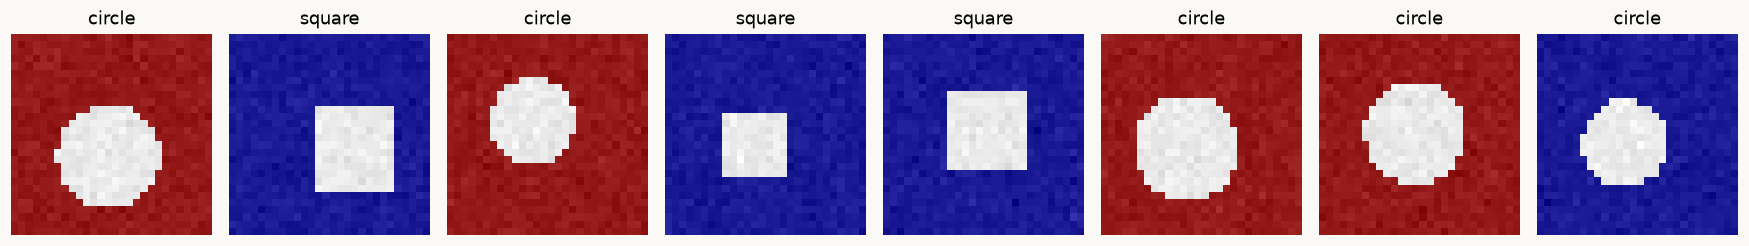

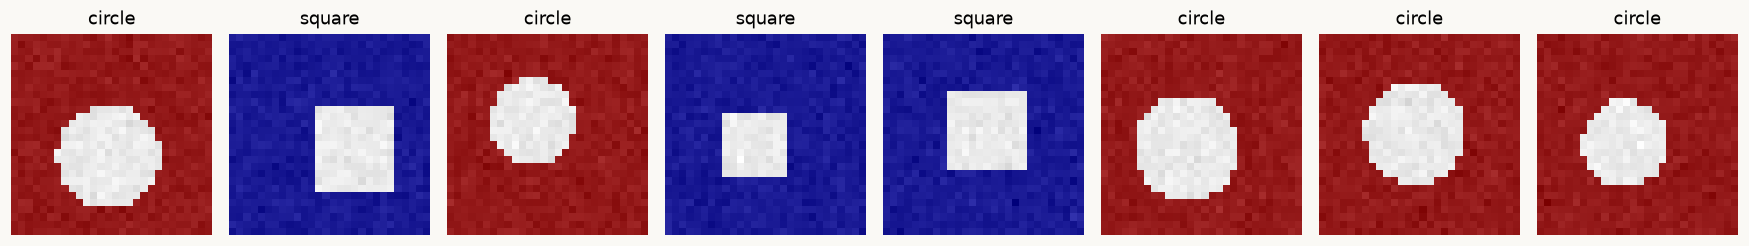

In [3]:
def paint(objects, background_ids, hide_object=False):
    mask, _, noise = objects
    palette = torch.tensor([[.58,.10,.10],[.10,.10,.58]],dtype=torch.float32)
    bg = palette[background_ids][:,:,None,None].expand(-1,-1,28,28)
    visible = torch.zeros_like(mask) if hide_object else mask
    return (bg*(1-visible) + .92*visible + noise).clamp(0,1)

def repeat_objects(objects):
    return tuple(torch.cat([t,t]) for t in objects)

def training_set(objects, correlation, seed, balanced=False):
    twice = repeat_objects(objects)
    labels = twice[1]
    if balanced:
        bg = torch.cat([objects[1],1-objects[1]])
    else:
        match = torch.rand(len(labels),generator=torch.Generator().manual_seed(seed)) < correlation
        bg = torch.where(match,labels,1-labels)
    return paint(twice,bg), labels, bg

CORRELATION = .98  # 자율 실험: .5, .8, .98. 변경 시 이 셀부터 다시 실행합니다.
EPOCHS = 10        # test를 보기 전에 고정합니다.
assert .0 <= CORRELATION <= 1.0
train_objects = make_objects(384,101)
val_objects = make_objects(96,202)
test_objects = make_objects(192,303)
xb,yb,bgb = training_set(train_objects,CORRELATION,501)
xc,yc,bgc = training_set(train_objects,CORRELATION,501,balanced=True)
vb,vy,_ = training_set(val_objects,CORRELATION,502)
vc,_,_ = training_set(val_objects,CORRELATION,502,balanced=True)
assert torch.equal(yb,yc) and len(yb) == len(yc)
mask = repeat_objects(train_objects)[0].expand(-1,3,-1,-1).bool()
assert torch.equal(xb[mask],xc[mask]), '전경 픽셀은 같아야 합니다.'
print('biased 실제 배경-라벨 일치율:', float((bgb == yb).float().mean()))
print('balanced 실제 배경-라벨 일치율:', float((bgc == yc).float().mean()))
print('고유 물체 train/val/test:',384,96,192,'| 학습 이미지 수:',len(yb))
gallery(xb,yb)
gallery(xc,yc)

### 데이터 검토
처음 몇 장만 보는 것으로 전체 상관을 판단하지 않습니다. 아래 표에서 클래스마다 두 배경의 개수를 확인합니다.
`balanced`는 같은 물체의 배경만 바꾸는 수집/증강을 흉내 냅니다. 실제 사진의 배경 교체는 조명·그림자도 바꿀 수 있어 이 실험처럼 완벽히 통제하기 어렵습니다.

In [4]:
rows = ['| train set | shape | red | blue |','|---|---|---:|---:|']
for name,y,bg in [('biased',yb,bgb),('balanced',yc,bgc)]:
    for label in [0,1]:
        counts = [int(((y==label)&(bg==color)).sum()) for color in [0,1]]
        rows.append(f'| {name} | {NAMES[label]} | {counts[0]} | {counts[1]} |')
display(Markdown('\n'.join(rows)))

| train set | shape | red | blue |
|---|---|---:|---:|
| biased | circle | 376 | 8 |
| biased | square | 8 | 376 |
| balanced | circle | 192 | 192 |
| balanced | square | 192 | 192 |

## 2. 같은 구조와 학습 예산으로 모델 두 개 만들기
두 모델은 같은 초기 가중치·배치 순서·optimizer·epoch 수를 사용합니다. 변경한 것은 학습 배경입니다.
validation은 각 학습 환경과 같은 배경 규칙으로 구성하며 학습 관찰에만 씁니다. **두 모델 모두 미리 정한 마지막 epoch**로 평가합니다.
test 결과가 좋은 epoch를 고르는 코드는 없습니다.

A: biased training


epoch  1/10 | train CE 0.466 | val acc 0.979


epoch 10/10 | train CE 0.104 | val acc 0.979
elapsed: 0.3s

B: balanced backgrounds
epoch  1/10 | train CE 0.693 | val acc 0.818


epoch 10/10 | train CE 0.050 | val acc 0.995
elapsed: 0.3s


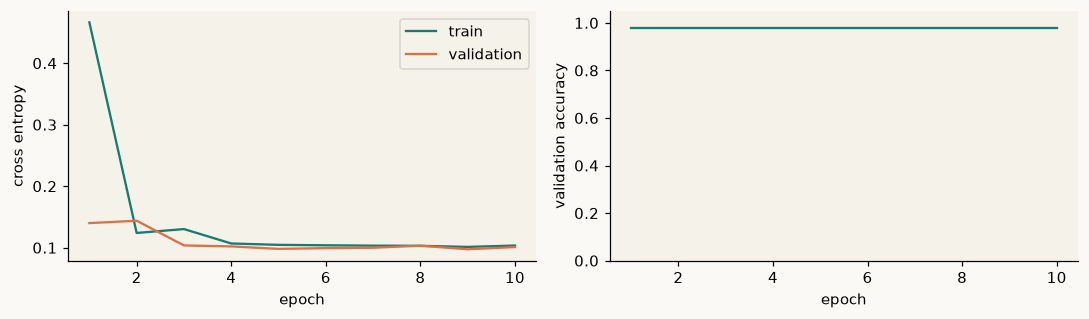

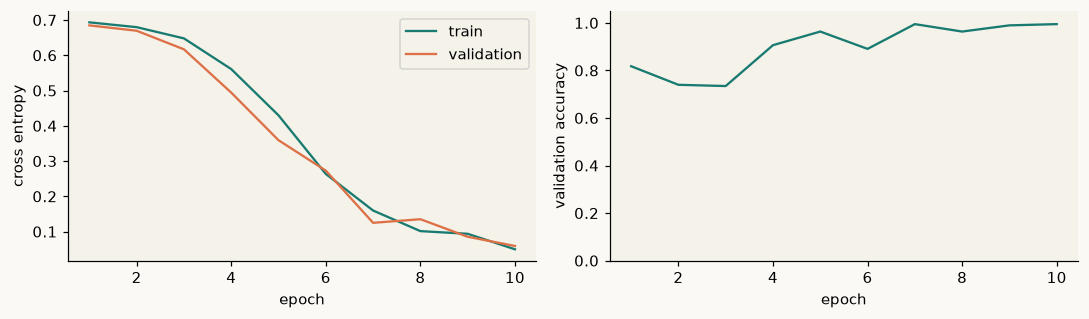

In [5]:
print('A: biased training')
biased_model,biased_history,initial_a = train_model(xb,yb,vb,vy,EPOCHS)
print('\nB: balanced backgrounds')
balanced_model,balanced_history,initial_b = train_model(xc,yc,vc,vy,EPOCHS)
assert all(torch.equal(initial_a[k],initial_b[k]) for k in initial_a)
models = {'biased': biased_model, 'balanced': balanced_model}
show_history(biased_history)
show_history(balanced_history)

## 3. 시험지의 배경 규칙만 바꾸기 · 핵심 5분
**실행 전 예상:** 각 모델에 대해 아래 세 조건의 정확도 순서를 적으세요.

1. `matched`: 모든 원은 붉은색, 모든 정사각형은 푸른색. 강한 상관이 유지됩니다.
2. `swapped`: 같은 물체의 배경만 반대로 바꿉니다.
3. `balanced`: 같은 test 물체를 양쪽 배경에서 모두 평가합니다.

matched는 학습과 **같은 상관 방향**이며 학습의 98%를 정확히 재현한 분포는 아닙니다.
조건 사이에 test 물체를 공유하는 것은 배경만 통제하려는 의도입니다. 이를 train/test 누출과 혼동하지 마세요.

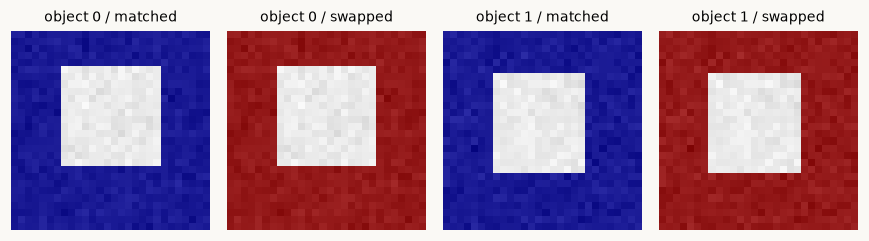

| model | condition | images | accuracy | CE |
|---|---|---:|---:|---:|
| biased | matched | 192 | 1.000 | 0.020 |
| biased | swapped | 192 | 0.000 | 3.868 |
| biased | balanced | 384 | 0.500 | 1.944 |
| balanced | matched | 192 | 0.995 | 0.051 |
| balanced | swapped | 192 | 0.990 | 0.062 |
| balanced | balanced | 384 | 0.992 | 0.057 |

In [6]:
ty = test_objects[1]
matched = paint(test_objects,ty)
swapped = paint(test_objects,1-ty)
both_objects = repeat_objects(test_objects)
balanced_test = paint(both_objects,torch.cat([ty,1-ty]))
test_conditions = {'matched':(matched,ty),'swapped':(swapped,ty),
                   'balanced':(balanced_test,both_objects[1])}
foreground = test_objects[0].expand(-1,3,-1,-1).bool()
assert torch.equal(matched[foreground],swapped[foreground])
gallery(torch.stack([matched[0],swapped[0],matched[1],swapped[1]]),
    titles=['object 0 / matched','object 0 / swapped','object 1 / matched','object 1 / swapped'],n=4)
results = {}
table = ['| model | condition | images | accuracy | CE |','|---|---|---:|---:|---:|']
for name,net in models.items():
    results[name] = {}
    for condition,(x,y) in test_conditions.items():
        result = evaluate(net,x,y); results[name][condition] = result
        table.append(f"| {name} | {condition} | {len(y)} | {result['accuracy']:.3f} | {result['loss']:.3f} |")
display(Markdown('\n'.join(table)))

### 같은 물체의 예측이 얼마나 뒤집혔나?
정확도 차이 외에 **배경 교체 전후 예측이 달라진 물체 비율**도 봅니다. 이것은 이 실험에서 배경 변화에 민감하다는 증거입니다.
정확도가 낮거나 예측이 바뀐 것만으로 모델 내부의 모든 계산을 설명할 수는 없습니다.

biased | 배경 교체 시 예측 변경 비율: 1.0
balanced | 배경 교체 시 예측 변경 비율: 0.005


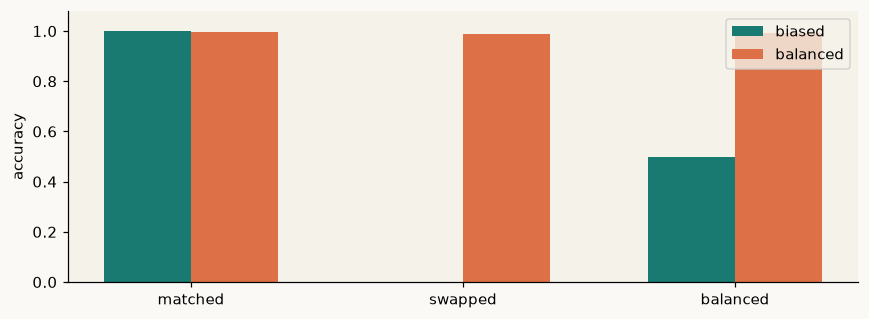

In [7]:
flip_rates = {}
fig, ax = plt.subplots(figsize=(8,3))
positions = np.arange(3)
for j,(name,net) in enumerate(models.items()):
    values = [results[name][c]['accuracy'] for c in test_conditions]
    ax.bar(positions+(j-.5)*.32,values,width=.32,label=name)
    p = results[name]['matched']['logits'].argmax(1)
    q = results[name]['swapped']['logits'].argmax(1)
    flip_rates[name] = float((p!=q).float().mean())
    print(name, '| 배경 교체 시 예측 변경 비율:', round(flip_rates[name],3))
ax.set_xticks(positions,list(test_conditions)); ax.set(ylabel='accuracy',ylim=(0,1.08))
ax.legend(); plt.tight_layout(); plt.show()

## 4. 어떤 클래스를 틀렸나? · 핵심 4분
`MODEL`과 `CONDITION`을 바꿔 혼동 행렬을 비교합니다. 행은 실제 라벨, 열은 예측입니다.
**질문:** 정확도 한 숫자에서 감춰졌던 클래스별 오류가 있나요? 모든 원을 정사각형으로, 모든 정사각형을 원으로 예측하는 것과 한 클래스만 예측하는 것은 어떻게 다른가요?

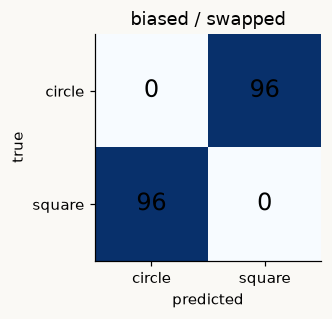

클래스별 recall: {'circle': np.float64(0.0), 'square': np.float64(0.0)}
오분류 예시


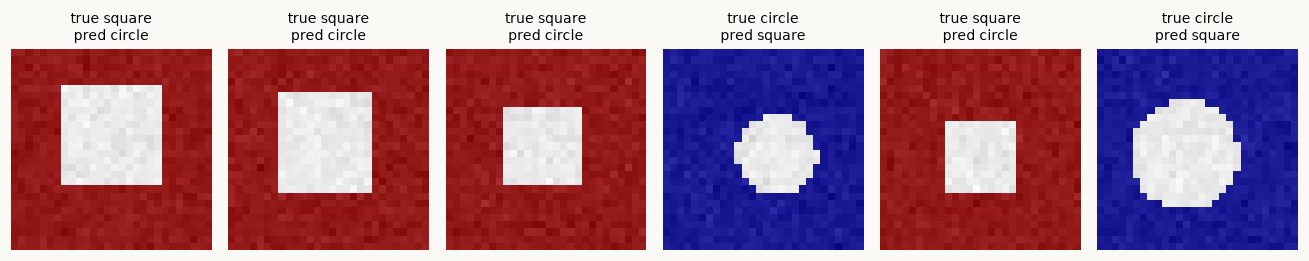

In [8]:
MODEL = 'biased'       # 'biased' 또는 'balanced'
CONDITION = 'swapped'  # 'matched', 'swapped', 'balanced'
r = results[MODEL][CONDITION]
cm = r['cm'].numpy()
fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(cm,cmap='Blues',vmin=0,vmax=max(cm.max(),1))
for (i,j),v in np.ndenumerate(cm): ax.text(j,i,str(v),ha='center',va='center',fontsize=16)
ax.set_xticks([0,1],NAMES); ax.set_yticks([0,1],NAMES)
ax.set(xlabel='predicted',ylabel='true',title=f'{MODEL} / {CONDITION}')
plt.tight_layout(); plt.show()
recall = cm.diagonal()/cm.sum(1).clip(min=1)
print('클래스별 recall:', dict(zip(NAMES,recall.round(3))))
x,y = test_conditions[CONDITION]
pred = r['logits'].argmax(1)
wrong = torch.where(pred!=y)[0][:6]
chosen = wrong if len(wrong) else torch.arange(6)
print('오분류 예시' if len(wrong) else '오분류 없음: 정상 예시')
gallery(x[chosen],titles=[f'true {NAMES[y[i]]}\npred {NAMES[pred[i]]}' for i in chosen],n=6)

## 5. 모양을 지워도 정답을 맞힐까? · 핵심 6분
이번에는 배경을 그대로 두고 **도형 전체를 제거**합니다. 평가 라벨은 원래 물체의 라벨을 그대로 사용합니다.
따라서 이 점수는 “없는 물체를 인식한 정확도”가 아니라 **배경만으로 원래 라벨을 얼마나 예측하는가**입니다.
**예상:** biased와 balanced 중 어느 모델이 배경만 보고도 높은 점수를 얻을까요?

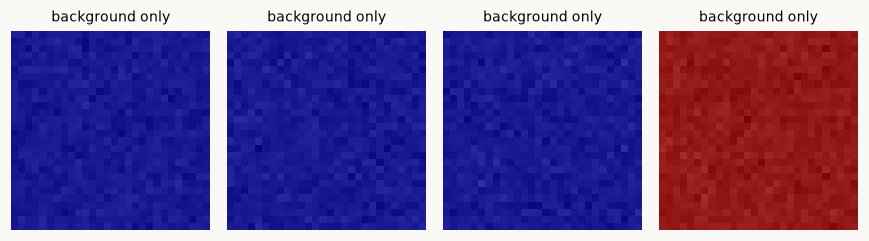

biased: 원래 라벨에 대한 배경-only 일치율 1.000
balanced: 원래 라벨에 대한 배경-only 일치율 0.500


In [9]:
background_only = paint(test_objects,ty,hide_object=True)
gallery(background_only[:4],titles=['background only']*4,n=4)
background_results = {}
for name,net in models.items():
    r = evaluate(net,background_only,ty)
    background_results[name] = r
    print(f"{name}: 원래 라벨에 대한 배경-only 일치율 {r['accuracy']:.3f}")

### 15분 활동의 결론 쓰기
| 질문 | 관찰한 수치/이미지 | 그 증거가 뒷받침하는 주장 |
|---|---|---|
| 배경을 바꾸면 예측이 얼마나 달라졌나? | 작성 | 작성 |
| 배경-only의 점수는 무엇을 뜻하나? | 작성 | 작성 |
| 배경을 균형 있게 수집한 효과는? | 작성 | 작성 |

**자가 확인:** 맞힌 이유를 알려면 평가 조건을 바꿔야 합니다. 배경 균형화가 이 장난감 문제에서 도움이 되어도 실제 환경의 모든 지름길을 제거했다는 뜻은 아닙니다.
차이가 예상보다 작으면 배경 상관율·학습 정도·표본 수를 점검하세요. 원하는 결론이 나올 때까지 test에 맞춰 설정을 고르지 않습니다.

## 6. 비교의 조건을 점검하기 · 확장
두 모델이 같은 초기값과 표본 수로 학습했는지 다시 확인합니다. 한 seed의 결과는 여러 번 반복한 평균과 다릅니다.
`balanced` test의 384장은 192개 물체의 쌍이며 독립 물체 384개로 취급해서는 안 됩니다.

In [10]:
assert all(torch.equal(initial_a[k],initial_b[k]) for k in initial_a)
assert len(xb)==len(xc) and torch.equal(yb,yc)
assert len(biased_history['train_loss']) == len(balanced_history['train_loss']) == EPOCHS
assert float((bgc==yc).float().mean()) == .5
assert len(ty) == 192 and len(balanced_test) == 2*len(ty)
print('확인: 같은 초기값·학습 예산·전경·라벨, 배경 균형 50%, paired test 192개 물체')

확인: 같은 초기값·학습 예산·전경·라벨, 배경 균형 50%, paired test 192개 물체


## 7. 작은 실험 보고서 저장
네 문장을 자신의 관찰로 바꾸세요. 실제 측정값과 글은 `outputs/week02_concept/report.json`에 저장합니다.
Colab 파일 패널에서 다운로드하거나 출력이 포함된 ipynb를 저장하세요.

In [11]:
reflection = {
    '질문': '배경과 라벨의 상관을 줄이면 배경 교체에 덜 민감해지는가?',
    '방법': '고정한 조건과 바꾼 변수를 내 말로 작성하세요.',
    '증거': '표에서 실제 관측한 정확도·예측 변경 비율을 인용하세요.',
    '한계와 다음 실험': '다른 seed 또는 다른 배경·도형에서 확인할 내용을 작성하세요.'}
metrics = {'seed': SEED, 'epochs': EPOCHS, 'correlation': CORRELATION,
    'train_images':len(yb), 'test_unique_objects':len(ty), 'flip_rates':flip_rates,
    'scores':{name:{cond:{'accuracy':r['accuracy'],'ce':r['loss'],'confusion':r['cm'].tolist()}
       for cond,r in group.items()} for name,group in results.items()},
    'background_only_label_agreement':{name:r['accuracy'] for name,r in background_results.items()}}
out = Path('outputs/week02_concept'); out.mkdir(parents=True,exist_ok=True)
(out/'report.json').write_text(json.dumps({'metrics':metrics,'reflection':reflection},ensure_ascii=False,indent=2),encoding='utf-8')
display(Markdown('\n'.join(f'- **{k}**: {v}' for k,v in reflection.items())))
print('저장:',out/'report.json')

- **질문**: 배경과 라벨의 상관을 줄이면 배경 교체에 덜 민감해지는가?
- **방법**: 고정한 조건과 바꾼 변수를 내 말로 작성하세요.
- **증거**: 표에서 실제 관측한 정확도·예측 변경 비율을 인용하세요.
- **한계와 다음 실험**: 다른 seed 또는 다른 배경·도형에서 확인할 내용을 작성하세요.

저장: outputs\week02_concept\report.json


### 자율 실험 · 하나를 선택하세요
1. **상관율:** `.5`, `.8`, `.98`을 비교합니다. 1부터 새 모델로 실행하고 matched/swapped 결과를 함께 기록하세요.
2. **반복:** 준비 셀 아래 `SEED`를 17·18·19로 바꾸고 두 모델을 다시 학습하세요. 데이터 seed를 유지하면 초기값/배치 순서의 변동을 비교합니다. 평균과 최솟값·최댓값을 쓰세요.
3. **새 시험지:** 다른 배경색이나 원/정사각형의 새로운 위치를 정합니다. 테스트 전에 평가 가설을 적고 `paint` 또는 `make_objects`를 복사해 별도 조건을 만드세요.

| 변경한 변수 | 고정한 변수 | matched | swapped | 예측 변경 비율 | 해석 |
|---|---|---|---|---|---|
| 작성 | 작성 | 측정값 | 측정값 | 측정값 | 작성 |

**해설 방향:** 배경-only에서도 원래 라벨을 맞히면 모양이 없는 단서만으로도 답을 얻었다는 뜻입니다.
배경 교체와 물체 제거는 서로 다른 개입이므로 함께 해석합니다. balanced 모델도 충분히 학습하지 못하거나 다른 단서에 의존할 수 있습니다.
실험 결과를 본 뒤 바꾼 설정은 탐색으로 표시하고, 최종 주장은 별도 보류 데이터로 확인하세요.

### 출처와 실제 이미지 확장
- [Geirhos et al.: Shortcut Learning](https://arxiv.org/abs/2004.07780) — 문제 설정의 배경. 이 노트북은 논문 실험의 재현이 아닙니다.
- [PyTorch: 손실과 최적화](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)
- 기존 `practice.ipynb`의 CIFAR10 증강 비교와 `homework_optional.ipynb`로 실제 이미지 실험을 확장할 수 있습니다.